# Model initialization, data preparation

### Imports, hyperparameters definition

In [1]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, SubsetRandomSampler
from transformers import CamembertTokenizer, CamembertTokenizerFast, CamembertForSequenceClassification
from torch.optim import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import nltk
import re
import seaborn as sns
import spacy
import random
import os

from collections import defaultdict
from tqdm import tqdm

nltk.download('punkt_tab', quiet=True)

SAMPLE_SIZE_TRAIN = 500
SAMPLE_SIZE_VAL = 100
BATCH_SIZE = 16
NUM_EPOCHS = 20

DATA_DIR = "data"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

### Extract informal texts from movie subtitles (srt files)

In [2]:
def extract_srt(file_path):
    """
    Extracts and cleans text content from an SRT subtitle file.
    """

    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()

    blocks = re.split(r"\n\s*\n", content)

    new_blocks = []

    for block in blocks:
        lines = block.strip().split("\n")

        lines = [line for line in lines if not re.match(r"^\d+$", line)]
        lines = [line for line in lines if not re.match(r"^\d{2}:\d{2}:\d{2},", line)]

        concat_lines = " ".join(lines)

        concat_lines = re.sub(r"<.*?>", "", concat_lines)
        concat_lines = re.sub(r"\{\\.*?\}", "", concat_lines)
        concat_lines = re.sub(r"\[.*?\]", "", concat_lines)
        concat_lines = re.sub(r"^\s*[\-*–—]+", "", concat_lines)
        concat_lines = re.sub(r"\s+", " ", concat_lines).strip()
        if concat_lines:
            new_blocks.append(concat_lines)

    return " ".join(new_blocks)

files = ["Asterix.srt", "Bronzes.srt", "Intouchables.srt", "Negociateur.srt", "Tuches.srt"]
informal_text = " ".join(extract_srt(os.path.join(DATA_DIR, "subtitles", f)) for f in files)
informal_sent = nltk.sent_tokenize(informal_text, language='french')

### Extract formal texts from books



In [3]:
def extract_book(path):
    """
    Extracts text from book (txt file)
    """
    with open(path, 'r', encoding='utf-8') as f:
        text = f.read()
        return text.replace('\n', ' ')


files = ["FleursDuMal.txt", "MadameBovary.txt", "Miserables.txt", "MonteCristo.txt", "RougeEtNoir.txt"]
formal_text = " ".join(extract_book(os.path.join(DATA_DIR, "books", f)) for f in files)
formal_sent = nltk.sent_tokenize(formal_text, language='french')

### Dataset, model creation

In [4]:
data = {
    "text": formal_sent + informal_sent,
    "label": [1]*len(formal_sent) + [0]*len(informal_sent)
}
df = pd.DataFrame(data)
train_texts, val_texts, train_labels, val_labels = train_test_split(df["text"], df["label"], test_size=0.2, random_state=SEED)


class FormalDataset(torch.utils.data.Dataset):
    """
    Dataset for handling formal/informal data.
    """
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        """
        Returns sample at given idx from the dataset.
        """
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        """
        return len(self.labels)

tokenizer = CamembertTokenizer.from_pretrained("camembert-base")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)

train_dataset = FormalDataset(train_encodings, train_labels)
val_dataset = FormalDataset(val_encodings, val_labels)

model = CamembertForSequenceClassification.from_pretrained("camembert-base", num_labels=2)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
model.to(device)

CamembertForSequenceClassification(
  (classifier): CamembertClassificationHead(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=768, out_features=2, bias=True)
  )
  (roberta): CamembertModel(
    (embeddings): CamembertEmbeddings(
      (word_embeddings): Embedding(32005, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): CamembertEncoder(
      (layer): ModuleList(
        (0-11): 12 x CamembertLayer(
          (attention): CamembertAttention(
            (self): CamembertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): 

### Sampler and loader

In [5]:
def random_sampler(dataset, sample_size):
    """
    Creates a random sampler.

    Generates a randomized subset of indices and wraps them
    in a PyTorch SubsetRandomSampler.

    (used during training to speed up the training)
    """
    indices = np.random.choice(len(dataset), sample_size, replace=False)
    return SubsetRandomSampler(indices)

train_sampler = random_sampler(train_dataset, SAMPLE_SIZE_TRAIN)
val_sampler = random_sampler(val_dataset, SAMPLE_SIZE_VAL)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, sampler=val_sampler)

# Training, testing the model

### Training

In [6]:
optimizer = Adam(model.parameters(), lr=1e-5)
loss_function = torch.nn.CrossEntropyLoss()

train_losses = []
val_losses = []
accuracies = []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_sampler = random_sampler(train_dataset, SAMPLE_SIZE_TRAIN)
    val_sampler = random_sampler(val_dataset, SAMPLE_SIZE_VAL)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, sampler=val_sampler)

    # TRAINING
    model.train()
    total_train_loss = 0

    for i, batch in enumerate(train_loader):
        if (i != 0) and (i % 10 == 0):
            print(f"Batch {i}/{len(train_loader)}, Loss: {loss.item():.4f}")

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDATION
    model.eval()
    total_val_loss = 0
    correct = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = loss_function(outputs.logits, labels)
            total_val_loss += loss.item()
            correct += (torch.argmax(outputs.logits, dim=1) == labels).sum().item()

    avg_val_loss = total_val_loss / len(val_loader)
    accuracy = correct / SAMPLE_SIZE_VAL

    val_losses.append(avg_val_loss)
    accuracies.append(accuracy)

    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Accuracy: {accuracy:.4f}")


Epoch 1/20
Batch 10/32, Loss: 0.6131
Batch 20/32, Loss: 0.5885
Batch 30/32, Loss: 0.5115
Train Loss: 0.5911 | Val Loss: 0.5206 | Accuracy: 0.7800

Epoch 2/20
Batch 10/32, Loss: 0.5506
Batch 20/32, Loss: 0.3860
Batch 30/32, Loss: 0.3125
Train Loss: 0.4850 | Val Loss: 0.4389 | Accuracy: 0.8000

Epoch 3/20
Batch 10/32, Loss: 0.4049
Batch 20/32, Loss: 0.4832
Batch 30/32, Loss: 0.4820
Train Loss: 0.4158 | Val Loss: 0.2808 | Accuracy: 0.8300

Epoch 4/20
Batch 10/32, Loss: 0.4013
Batch 20/32, Loss: 0.3129
Batch 30/32, Loss: 0.3336
Train Loss: 0.3210 | Val Loss: 0.2888 | Accuracy: 0.9000

Epoch 5/20
Batch 10/32, Loss: 0.3109
Batch 20/32, Loss: 0.2465
Batch 30/32, Loss: 0.2004
Train Loss: 0.2614 | Val Loss: 0.2238 | Accuracy: 0.9200

Epoch 6/20
Batch 10/32, Loss: 0.1254
Batch 20/32, Loss: 0.2162
Batch 30/32, Loss: 0.1897
Train Loss: 0.2044 | Val Loss: 0.1528 | Accuracy: 0.9500

Epoch 7/20
Batch 10/32, Loss: 0.1489
Batch 20/32, Loss: 0.0988
Batch 30/32, Loss: 0.1028
Train Loss: 0.1649 | Val Los

### Plot metrics evolution during learning

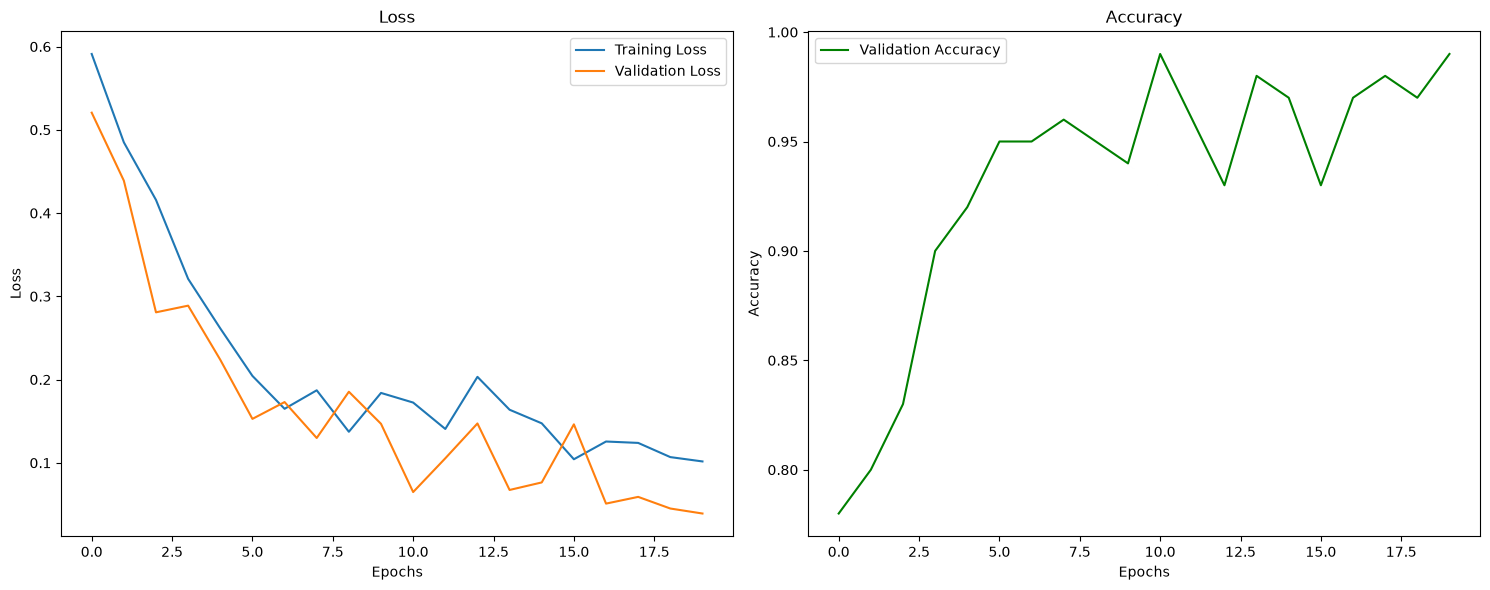

In [7]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Test the model on the entire validation set

In [8]:
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
model.eval()

total_loss, correct = 0, 0
with torch.no_grad():
    for batch in val_loader:
        inputs = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        labels = batch['labels'].to(device)
        outputs = model(**inputs)
        loss = loss_function(outputs.logits, labels)
        total_loss += loss.item()
        correct += (torch.argmax(outputs.logits, dim=1) == labels).sum().item()

final_loss = total_loss / len(val_loader)
final_accuracy = correct / len(val_dataset)

print(f"Val Loss: {final_loss:.4f} | Accuracy: {final_accuracy:.4f}")

Val Loss: 0.1074 | Accuracy: 0.9635


### Test the model on example sentences

In [10]:
def predict_formality(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    inputs.to(device)
    outputs = model(**inputs)
    proba = torch.softmax(outputs.logits, dim=1)
    return "Formal" if torch.argmax(proba) == 1 else "Informal"

print("Formal texts:\n")
print(predict_formality("Nous avons tous une mère: la terre."))
print(predict_formality("Je suis actuellement dans une situation périlleuse"))
print(predict_formality("Ne pouvez-vous pas m'arranger un rendez-vous en tête à tête avec lui?"))
print(predict_formality("Comment vous sentez-vous aujourd'hui?"))

print("\n")

print("Informal texts:\n")
print(predict_formality("Yo, tu peux m'aider ?"))
print(predict_formality("Salut, ça va ?"))
print(predict_formality("Wesh l'équipe"))
print(predict_formality("Il est vraiment bg ce gars"))

Formal texts:

Formal
Informal
Formal
Formal


Informal texts:

Informal
Informal
Informal
Informal


### Plot model labels probabilities of example sentences

In [11]:
def plot_formality_proba(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    inputs.to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    proba = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    fig, ax = plt.subplots(figsize=(10, 5))
    classes = ['Informal', 'Formal']

    bars = ax.bar(classes, proba, color=['#237E95', '#0B8532'])

    ax.set_ylim(0, 1)
    ax.set_ylabel('Probability')
    ax.set_title(f'{text}')
    plt.grid(axis='y', linestyle='--')

    plt.show()
    return proba

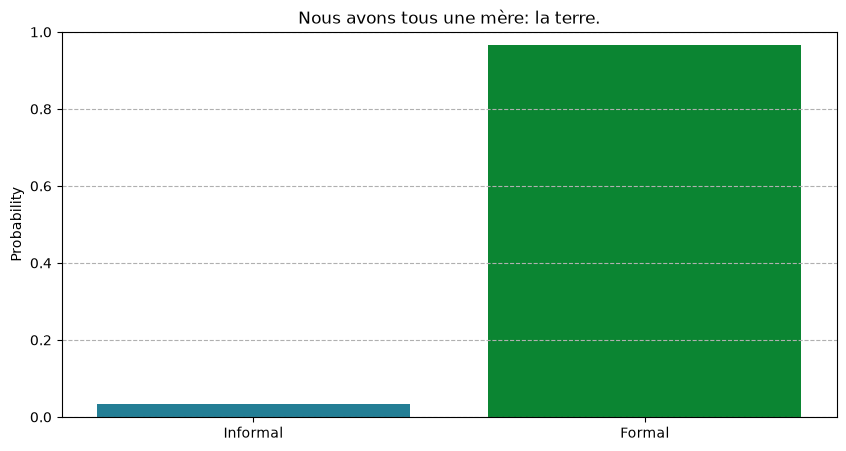

array([0.03320263, 0.9667974 ], dtype=float32)

In [12]:
plot_formality_proba("Nous avons tous une mère: la terre.", model, tokenizer)

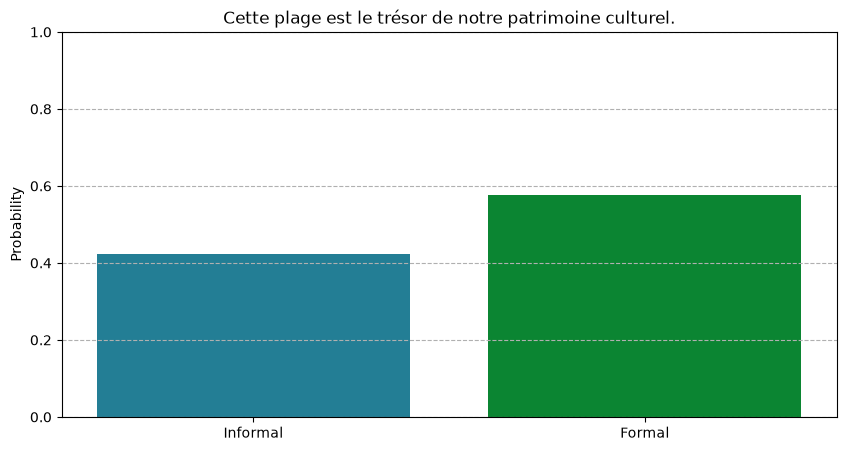

array([0.4231556, 0.5768444], dtype=float32)

In [13]:
plot_formality_proba("Cette plage est le trésor de notre patrimoine culturel.", model, tokenizer)

# Analysis of tokens and their influence on formality:

### Plot the contribution of each tokens to the formality decision in a given text

Probability that the text is formal: 95.33%

Most important words in the decision:
▁cela: 1.0000 (FORMAL)
ons: 0.8729 (FORMAL)
▁All: 0.6529 (FORMAL)
▁faire: 0.0386 (FORMAL)
<s>: 0.0294 (FORMAL)
</s>: -0.0232 (INFORMAL)


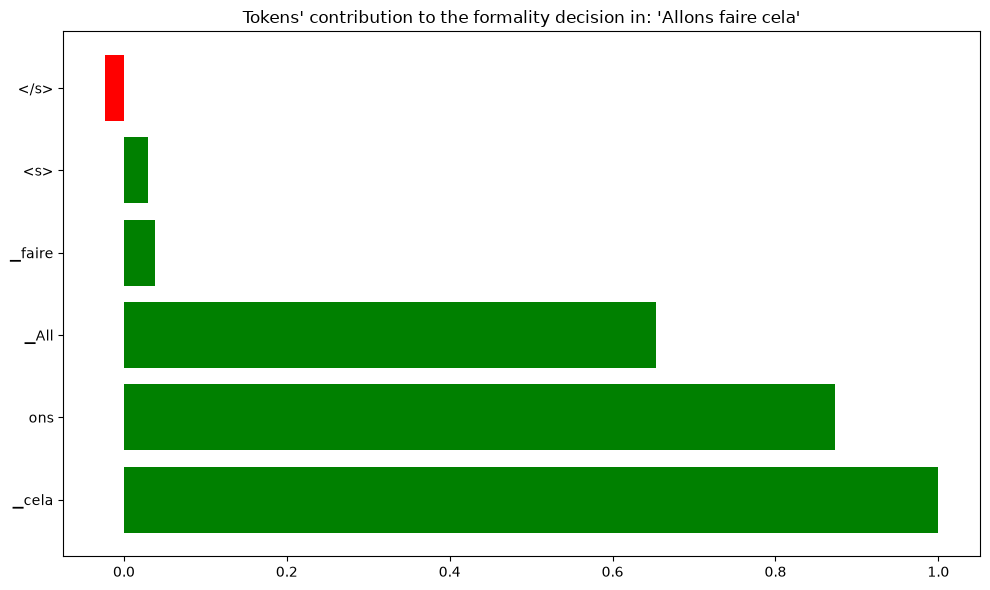

In [14]:
def analyze_text_contributions(model, tokenizer, text, device, n_samples=100):
    """Analyze the contribution of each token in the given text in formality decision
    Done by deleting tokens (masking)"""
    inputs = tokenizer(text, return_tensors="pt", truncation=True).to(device)
    baseline_prob = torch.softmax(model(**inputs).logits, dim=1)[0,1].item()

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    contributions = []

    for i, token in enumerate(tokens):
        # if token in ["[CLS]", "[SEP]", "[PAD]"]:
        #     continue

        masked_inputs = inputs.copy()
        masked_inputs["input_ids"] = inputs["input_ids"].clone()
        masked_inputs["input_ids"][0,i] = tokenizer.mask_token_id

        with torch.no_grad():
            masked_prob = torch.softmax(model(**masked_inputs).logits, dim=1)[0,1].item()

        delta = baseline_prob - masked_prob
        contributions.append({
            "position": i,
            "token": token,
            "contribution": delta,
            "abs_contribution": abs(delta)
        })

    max_val = max(abs(c["contribution"]) for c in contributions) + 1e-8
    for c in contributions:
        c["contribution"] /= max_val
        c["abs_contribution"] = abs(c["contribution"])

    contributions.sort(key=lambda x: x["abs_contribution"], reverse=True)

    return {
        "formal_prob": baseline_prob,
        "contributions": contributions
    }

text = "Allons faire cela"
analysis = analyze_text_contributions(model, tokenizer, text, device)

print(f"Probability that the text is formal: {analysis['formal_prob']:.2%}")
print("\nMost important words in the decision:")
for item in analysis["contributions"][:10]:
    print(f"{item['token']}: {item['contribution']:.4f} ({'FORMAL' if item['contribution'] > 0 else 'INFORMAL'})")

plt.figure(figsize=(10, 6))
contribs = [x["contribution"] for x in analysis["contributions"][:15]]
tokens = [x["token"] for x in analysis["contributions"][:15]]
colors = ['green' if c > 0 else 'red' for c in contribs]
plt.barh(tokens, contribs, color=colors)
plt.title("Tokens' contribution to the formality decision in: '" + text + "'")
plt.tight_layout()
plt.show()

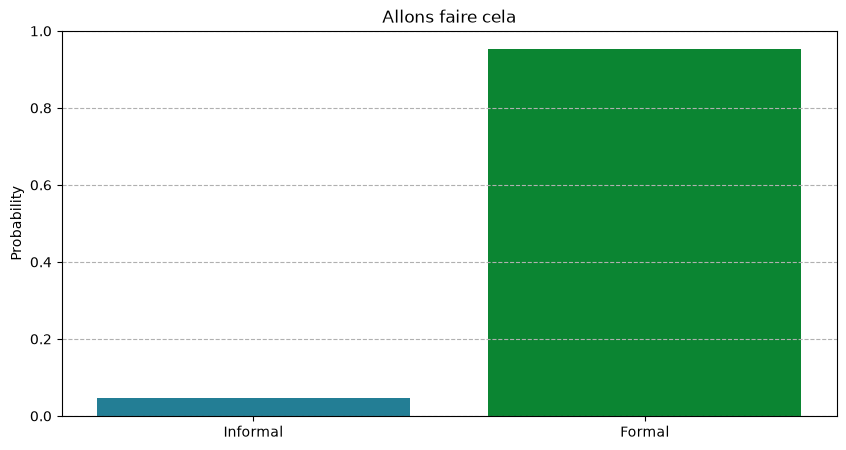

array([0.04674731, 0.9532526 ], dtype=float32)

In [15]:
plot_formality_proba(text, model, tokenizer)

### Displaying tokens with the most influence on the formality in the dataset

Most formal tokens
▁murmura: 1.000
bré: 0.939
▁voyait: 0.934
nal: 0.919
eusement: 0.890
vert: 0.872
art: 0.837
écri: 0.834
▁ainsi: 0.810
▁vieillard: 0.801
▁entendit: 0.792
récepteur: 0.777
▁alla: 0.773
▁disparu: 0.765
approcha: 0.762
▁regardait: 0.762
▁arriva: 0.751
▁distinguer: 0.744
out: 0.739
▁jouissance: 0.728

Most informal tokens
▁?: -0.896
▁Pas: -0.890
▁!: -0.849
▁:: -0.644
▁Non: -0.542
▁T: -0.498
▁Allez: -0.470
▁Avec: -0.405
▁Ca: -0.401
D: -0.332
▁ça: -0.326
▁All: -0.315
▁Mer: -0.290
▁minutes: -0.242
▁Tu: -0.240
appelle: -0.223
▁tellement: -0.199
hui: -0.198
▁C: -0.195
▁vais: -0.186


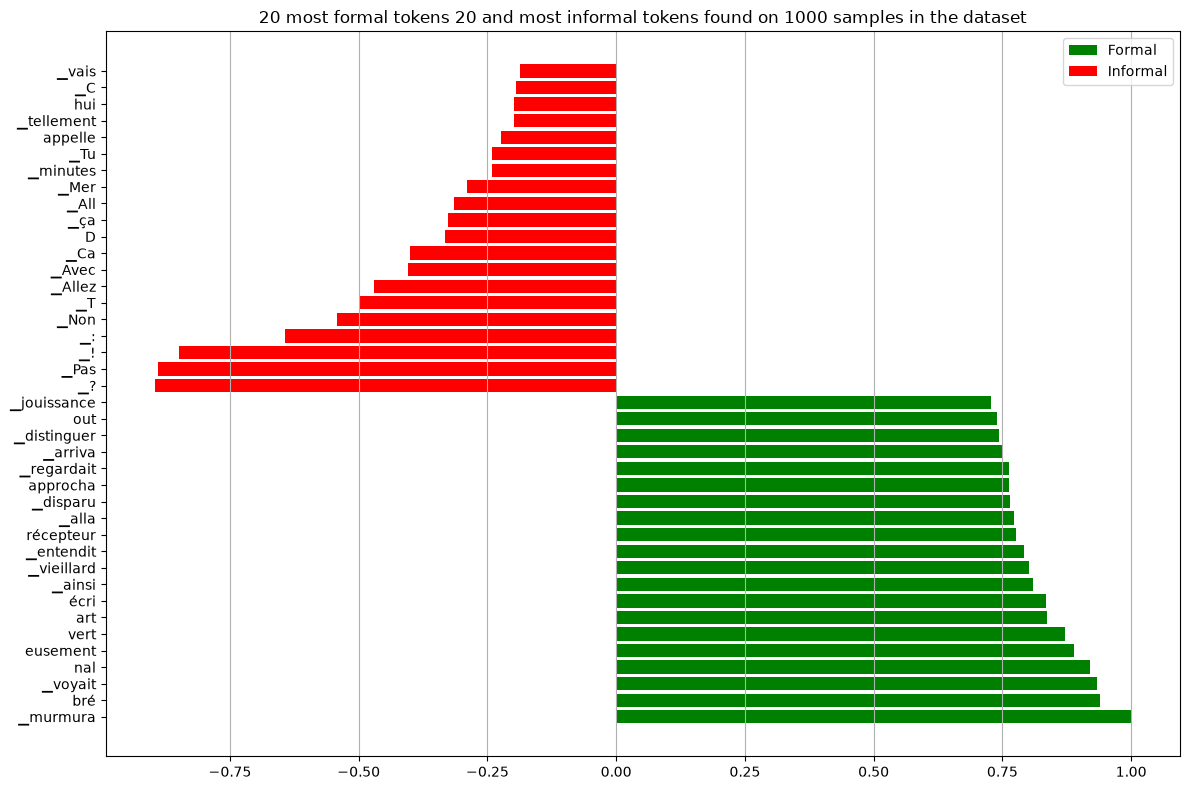

In [16]:
def analyze_token_contributions(model, tokenizer, dataset, device='cuda', sample_size=1000, top_n=20):
    """Returns the 'top_n' most formal / informal tokens found in the dataset on 'sample_size' samples"""
    indices = random.sample(range(len(dataset)), min(sample_size, len(dataset)))
    sampler = torch.utils.data.SubsetRandomSampler(indices)
    loader = DataLoader(dataset, batch_size=16, sampler=sampler)

    token_contribs = defaultdict(list)

    for batch in tqdm(loader, desc="Analysis of contributions"):
        texts = [tokenizer.decode(ids, skip_special_tokens=True)
                for ids in batch['input_ids']]

        for text in texts:
            analysis = analyze_text_contributions(model, tokenizer, text, device)

            for token_info in analysis['contributions']:
                token = token_info['token']

                token_contribs[token].append(token_info['contribution'])

    token_stats = {token: np.mean(vals) for token, vals in token_contribs.items() if len(vals) >= 3}


    formal_tokens = sorted([(k, v) for k, v in token_stats.items() if v > 0],
                          key=lambda x: x[1], reverse=True)[:top_n]
    informal_tokens = sorted([(k, v) for k, v in token_stats.items() if v < 0],
                            key=lambda x: x[1])[:top_n]

    return formal_tokens, informal_tokens

def plot_token_contributions(formal_tokens, informal_tokens):
    """Plot the given most formal / informal tokens"""
    plt.figure(figsize=(12, 8))

    tokens_pos, scores_pos = zip(*formal_tokens)
    plt.barh(tokens_pos, scores_pos, color='green', label='Formal')

    tokens_neg, scores_neg = zip(*informal_tokens)
    plt.barh(tokens_neg, scores_neg, color='red', label='Informal')

    plt.title(f"{len(tokens_pos)} most formal tokens {len(tokens_neg)} and most informal tokens found on 1000 samples in the dataset")
    plt.legend()
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()

formal, informal = analyze_token_contributions(model, tokenizer, train_dataset, device)
print("Most formal tokens")
for token, score in formal:
    print(f"{token}: {score:.3f}")

print("\nMost informal tokens")
for token, score in informal:
    print(f"{token}: {score:.3f}")

plot_token_contributions(formal, informal)

# Analysis of the influence of POS tags on formality

### Displaying the influence of POS tags on formalities



In [17]:
def spacy_pos_analysis(model, tokenizer, dataset, device='cuda', sample_size=1000):
    """Analysis of the average influence of POS tags on formality"""
    import spacy
    nlp = spacy.load("fr_core_news_sm")

    sampler = random_sampler(dataset, min(sample_size, len(dataset)))
    loader = DataLoader(dataset, batch_size=16, sampler=sampler)

    # same token ids as `tokenizer`, but also returns each token's character span
    fast_tokenizer = CamembertTokenizerFast.from_pretrained("camembert-base")

    pos_stats = defaultdict(list)

    for batch in tqdm(loader, desc="Analyzing...."):
        texts = [tokenizer.decode(ids, skip_special_tokens=True)
                for ids in batch['input_ids']]

        for text in texts:
            doc = nlp(text)
            analysis = analyze_text_contributions(model, tokenizer, text, device)

            # contributions are sorted by importance: put them back in sentence order
            contribs = [c['contribution'] for c in sorted(analysis['contributions'], key=lambda c: c['position'])]
            offsets = fast_tokenizer(text, truncation=True, return_offsets_mapping=True)['offset_mapping']

            for token in doc:
                if not token.is_punct and not token.is_space:
                    start, end = token.idx, token.idx + len(token)
                    # a word's contribution = mean contribution of the subwords that overlap it
                    word_contribs = [c for c, (s, e) in zip(contribs, offsets) if s < end and e > start]
                    if word_contribs:
                        pos_stats[token.pos_].append(np.mean(word_contribs))

    return {pos: np.mean(vals) for pos, vals in pos_stats.items()}

In [18]:
def plot_pos_influence(pos_stats, dataset_name = "DataSet"):
    sorted_pos = sorted(pos_stats.items(), key=lambda x: x[1], reverse=True)
    pos_tags, scores = zip(*sorted_pos)

    plt.figure(figsize=(10, 6))
    colors = ['green' if s > 0 else 'red' for s in scores]
    plt.barh(pos_tags, scores, color=colors)
    plt.title(f"Average influence on Formality for each POS tag: {dataset_name}")
    # plt.xlabel("Contribution moyenne à la classe 'formel'")
    plt.grid(axis='x')
    plt.show()

In [19]:
from torch.utils.data import Dataset

class UniqueStyleDataset(Dataset):
    """Dataset containing only one style of data (formal or informal)"""
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

    def __len__(self):
        return len(self.encodings['input_ids'])

formal_encodings = tokenizer(formal_sent, truncation=True, padding=True, max_length=128)
informal_encodings = tokenizer(informal_sent, truncation=True, padding=True, max_length=128)

formal_dataset = UniqueStyleDataset(formal_encodings)
informal_dataset = UniqueStyleDataset(informal_encodings)


Average contribution per POS-Tag:
PUNCT: -0.35
ADV: -0.20
PRON: -0.19
PROPN: -0.18
SCONJ: -0.15
CCONJ: -0.10
ADJ: -0.05
VERB: -0.05
AUX: -0.05
DET: -0.05
NUM: -0.04
ADP: -0.03
NOUN: -0.01
X: -0.00


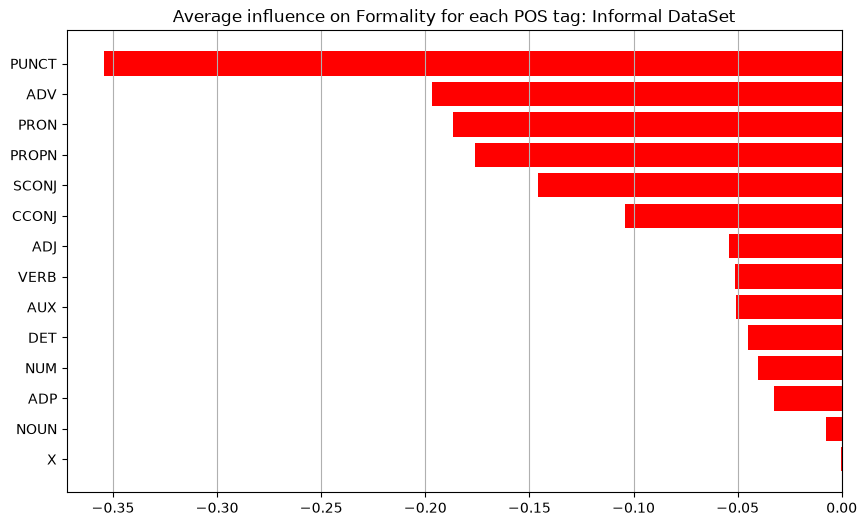

In [20]:
pos_stats_informal = spacy_pos_analysis(model, tokenizer, informal_dataset, device)

print("\nAverage contribution per POS-Tag:")
for pos, score in sorted(pos_stats_informal.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{pos}: {score:.2f}")

plot_pos_influence(pos_stats_informal, "Informal DataSet")


Average contribution per POS-Tag:
SYM: 0.43
PUNCT: 0.38
PROPN: 0.31
VERB: 0.28
NOUN: 0.27
ADJ: 0.24
X: 0.23
AUX: 0.19
ADV: 0.17
NUM: 0.16
PRON: 0.14
CCONJ: 0.11
SCONJ: 0.09
ADP: 0.08
DET: 0.08
INTJ: 0.01


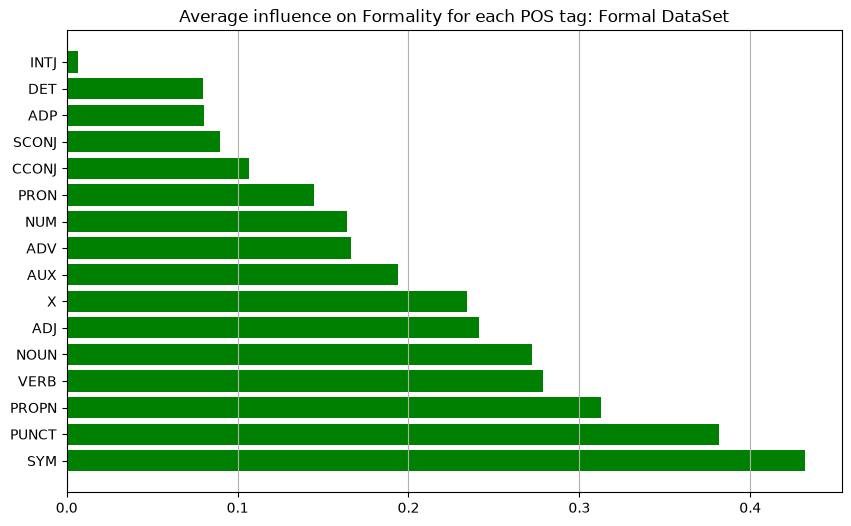

In [21]:
pos_stats_formal = spacy_pos_analysis(model, tokenizer, formal_dataset, device)

print("\nAverage contribution per POS-Tag:")
for pos, score in sorted(pos_stats_formal.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{pos}: {score:.2f}")

plot_pos_influence(pos_stats_formal, "Formal DataSet")

### Both styles side by side

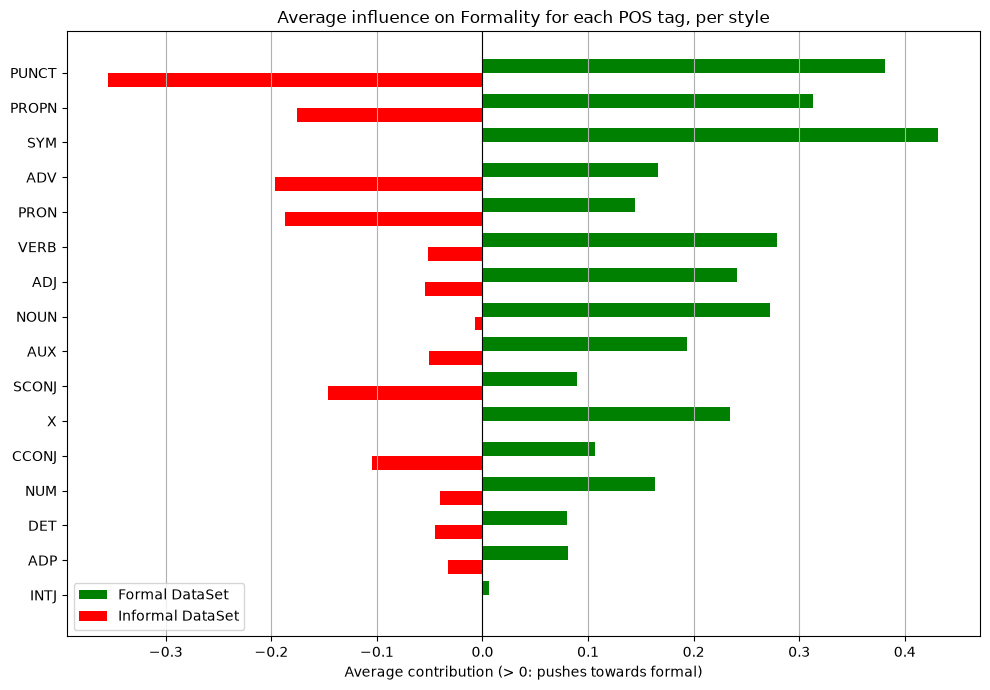

In [22]:
# both styles in one chart; tags sorted by how differently they act in the two styles
tags = sorted(set(pos_stats_formal) | set(pos_stats_informal),
              key=lambda t: pos_stats_formal.get(t, 0) - pos_stats_informal.get(t, 0))
y = np.arange(len(tags))
height = 0.4

plt.figure(figsize=(10, 7))
plt.barh(y + height/2, [pos_stats_formal.get(t, 0) for t in tags], height, label='Formal DataSet', color='green')
plt.barh(y - height/2, [pos_stats_informal.get(t, 0) for t in tags], height, label='Informal DataSet', color='red')
plt.yticks(y, tags)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Average influence on Formality for each POS tag, per style")
plt.xlabel("Average contribution (> 0: pushes towards formal)")
plt.legend()
plt.grid(axis='x')
plt.tight_layout()
plt.show()

### Formality Distribution for each POS tag

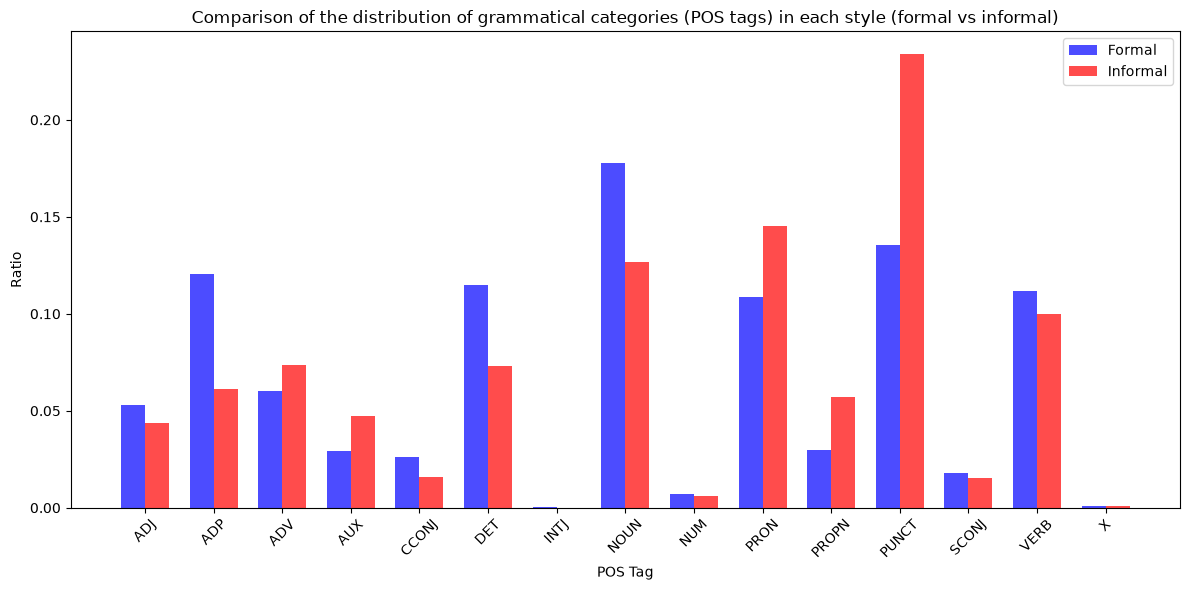

In [23]:
import spacy
nlp = spacy.load("fr_core_news_sm")

def compare_pos_distributions(formal_sents, informal_sents, sample_size=3000):
    """Comparison of the distribution of grammatical categories (POS tags) in each style (formal vs informal)"""
    def get_pos_counts(sentences):
        pos_counts = defaultdict(int)
        for sent in random.sample(sentences, min(sample_size, len(sentences))):
            doc = nlp(sent)
            for token in doc:
                pos_counts[token.pos_] += 1
        return pos_counts

    formal_counts = get_pos_counts(formal_sents)
    informal_counts = get_pos_counts(informal_sents)

    total_formal = sum(formal_counts.values())
    total_informal = sum(informal_counts.values())

    return {
        'formal': {k: v/total_formal for k, v in formal_counts.items()},
        'informal': {k: v/total_informal for k, v in informal_counts.items()}
    }

pos_comparison = compare_pos_distributions(formal_sent, informal_sent)

common_tags = sorted(set(pos_comparison['formal']) & set(pos_comparison['informal']))

x = np.arange(len(common_tags))
width = 0.35

formal_vals = [pos_comparison['formal'].get(tag, 0) for tag in common_tags]
informal_vals = [pos_comparison['informal'].get(tag, 0) for tag in common_tags]

plt.figure(figsize=(12,6))
plt.bar(x - width/2, formal_vals, width, label='Formal', color='blue', alpha=0.7)
plt.bar(x + width/2, informal_vals, width, label='Informal', color='red', alpha=0.7)

plt.xticks(x, common_tags, rotation=45)
plt.title('Comparison of the distribution of grammatical categories (POS tags) in each style (formal vs informal)')
plt.xlabel('POS Tag')
plt.ylabel('Ratio')
plt.legend()
plt.tight_layout()
plt.show()